MD**Intelligent Vision Systems · Lab 5 · Self-Driving Car Vision: Finding Lane Lines**  
Companion to **Lecture 5 (Part II) — Computer Vision for Self-Driving Cars**  
Dr. Muhammad Kazim · Department of Intelligent Systems, University of Lahore

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Kazimbalti/intelligent-vision-systems/blob/main/LAB/Lab_5/01-color-selection.ipynb) &nbsp; [Lecture 5 Part II slides](https://kazimbalti.github.io/intelligent-vision-systems/lectures/05_SDC_Lane_Finding.html#/coding-up-a-colour-selection) &nbsp; [All Lab 5 notebooks](https://kazimbalti.github.io/intelligent-vision-systems/labs.html#lab-5-lane-lines)

# Lab 5A · Colour Selection

_Lecture 5 Part II, Section 2: Colour Selection._

Lane lines are painted **white** or **yellow** so that *people* can see them. Our first idea is to use the same cue: keep only the
bright pixels and black out everything else. You will:

1. load a road image and look at it as a NumPy array,
2. write a colour-threshold selection in a few lines of NumPy,
3. tune the thresholds (the Udacity quiz),
4. see where RGB thresholds fail — and fix it with the **HLS** colour space from Lecture 5 Part I.

In [1]:
# Setup (only needed on Google Colab or a fresh environment).
# Uncomment the next line to install the packages this notebook uses:
# !pip install -q opencv-python numpy matplotlib

import os, urllib.request

# Fetch the lab images if they are not next to the notebook.
RAW = "https://raw.githubusercontent.com/Kazimbalti/intelligent-vision-systems/main/LAB/Lab_5"
for f in ['test.jpg', 'test_images/solidYellowCurve2.jpg']:
    if not os.path.exists(f):
        os.makedirs(os.path.dirname(f) or ".", exist_ok=True)
        urllib.request.urlretrieve(f"{RAW}/{f}", f)
print("data ready")

data ready


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2

MD## 1. Read the image and print some stats

`mpimg.imread` returns an RGB array. **Careful:** for a `.jpg` the values are `uint8` in 0–255, but for a `.png` they are
`float32` in 0–1 — your thresholds must match. (`cv2.imread` always gives `uint8`, but in **BGR** order.)

This image is: <class 'numpy.ndarray'> with dimensions: (540, 960, 3) and dtype: uint8


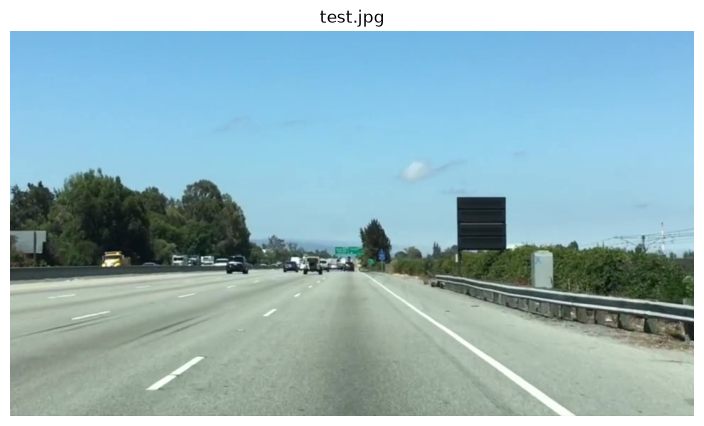

In [3]:
image = mpimg.imread("test.jpg")
print("This image is:", type(image), "with dimensions:", image.shape, "and dtype:", image.dtype)

ysize, xsize = image.shape[:2]

# Always make a *copy*: `color_select = image` would make both names point at the SAME array,
# so blacking out pixels in one would destroy the other.
color_select = np.copy(image)

plt.figure(figsize=(9, 5)); plt.imshow(image); plt.title("test.jpg"); plt.axis("off"); plt.show()

MD## 2. What colour is a lane line?

Print a few pixels on the white line and on the road. Pure white is `[255, 255, 255]`; asphalt is a darker grey.

In [4]:
for name, (row, col) in {"white lane line": (450, 656), "asphalt": (500, 480), "sky": (40, 300)}.items():
    print(f"{name:16s} (row={row}, col={col}) -> RGB = {image[row, col]}")

white lane line  (row=450, col=656) -> RGB = [249 255 248]
asphalt          (row=500, col=480) -> RGB = [120 133 123]
sky              (row=40, col=300) -> RGB = [122 190 235]


MD## 3. A colour selection in three lines of NumPy

`rgb_threshold` holds the **minimum** R, G and B values we accept. A pixel is rejected if **any** channel is below its
threshold (boolean OR `|`), and rejected pixels are set to black.

boolean mask shape: (540, 960) | pixels rejected: 0


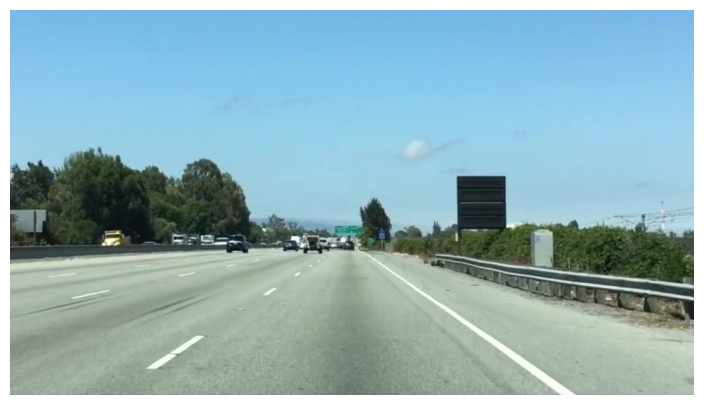

In [5]:
def color_selection(image, red_threshold, green_threshold, blue_threshold):
    rgb_threshold = [red_threshold, green_threshold, blue_threshold]
    color_select = np.copy(image)
    thresholds = (image[:, :, 0] < rgb_threshold[0]) \
               | (image[:, :, 1] < rgb_threshold[1]) \
               | (image[:, :, 2] < rgb_threshold[2])
    color_select[thresholds] = [0, 0, 0]
    return color_select, thresholds

# Thresholds of 0 keep every pixel - not useful yet!
out, thr = color_selection(image, 0, 0, 0)
print("boolean mask shape:", thr.shape, "| pixels rejected:", thr.sum())
plt.figure(figsize=(9, 5)); plt.imshow(out); plt.axis("off"); plt.show()

MD## 4. Quiz — tune the thresholds

Change the three values below until you keep as much of the lane lines as possible while blacking out almost everything else.

<details><summary><b>Show the answer</b> (try first!)</summary>

`red_threshold = green_threshold = blue_threshold = 200` keeps the lane lines clearly while removing almost everything else.
Some bright pixels near the horizon survive — we will remove those with a region mask in Lab 5B.
</details>

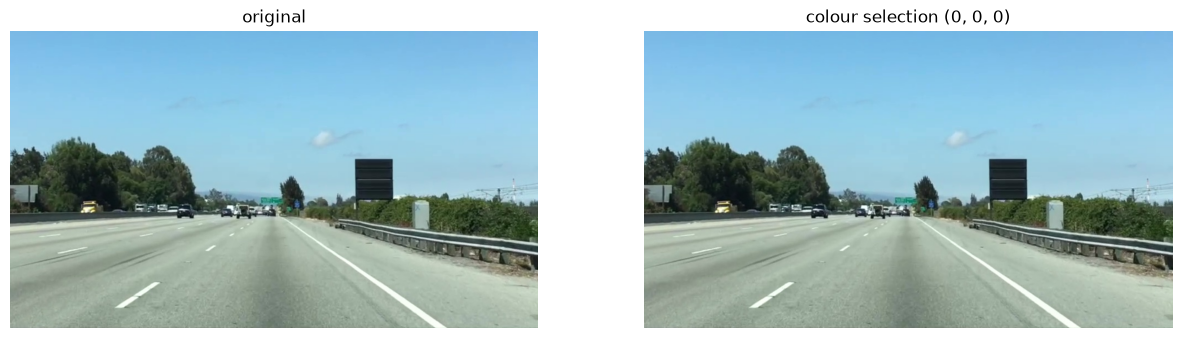

In [6]:
###### MODIFY THESE VARIABLES TO MAKE YOUR COLOR SELECTION
red_threshold = 0
green_threshold = 0
blue_threshold = 0
######

out, _ = color_selection(image, red_threshold, green_threshold, blue_threshold)
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].imshow(image); ax[0].set_title("original"); ax[0].axis("off")
ax[1].imshow(out); ax[1].set_title(f"colour selection {red_threshold, green_threshold, blue_threshold}"); ax[1].axis("off")
plt.show()
# mpimg.imsave("test-after.png", out)   # uncomment to save your result

MD### Optional: interactive sliders

If `ipywidgets` is available (it is on Colab), drag the sliders and watch the selection update.

In [7]:
try:
    from ipywidgets import interact, IntSlider
    def show(r=200, g=200, b=200):
        plt.figure(figsize=(9, 5)); plt.imshow(color_selection(image, r, g, b)[0]); plt.axis("off"); plt.show()
    s = dict(min=0, max=255, step=5, value=200)
    interact(show, r=IntSlider(**s), g=IntSlider(**s), b=IntSlider(**s))
except ImportError:
    print("ipywidgets not installed - skip this cell or `pip install ipywidgets`")

MD## 5. Where RGB thresholds fail: yellow lines

Yellow paint has a high R and G but a **low B**, so the RGB ≥ 200 rule throws it away. Shadows and evening light
also darken *white* lines below 200. A colour space that separates **brightness** from **hue** is far more robust —
this is exactly why we met HSV/HLS/LAB in Part I of this lecture.

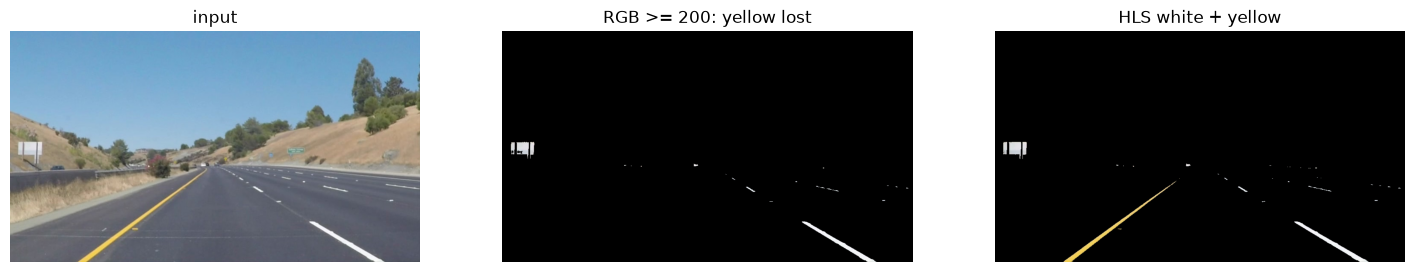

In [8]:
img2 = mpimg.imread("test_images/solidYellowCurve2.jpg")
rgb_out, _ = color_selection(img2, 200, 200, 200)

hls = cv2.cvtColor(img2, cv2.COLOR_RGB2HLS)              # H: 0-180, L: 0-255, S: 0-255 in OpenCV
white  = cv2.inRange(hls, (0, 200, 0),    (180, 255, 255))   # very light, any hue
yellow = cv2.inRange(hls, (15, 30, 115),  (35, 204, 255))    # hue ~ 30-70 deg, well saturated
mask = cv2.bitwise_or(white, yellow)
hls_out = cv2.bitwise_and(img2, img2, mask=mask)

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
for a, im, t in zip(ax, [img2, rgb_out, hls_out], ["input", "RGB >= 200: yellow lost", "HLS white + yellow"]):
    a.imshow(im); a.set_title(t); a.axis("off")
plt.show()

MD## Takeaway

Colour selection is fast and intuitive, but on its own it keeps *every* bright thing (sky, cars, signs) and it is
sensitive to lighting. Next we add **where** to look (Lab 5B) and then **shape** (edges, Lab 5C; lines, Lab 5D).

## Your turn — Lab 5A tasks

1. Report the thresholds you chose for `test.jpg` and **how many pixels** survive (use the boolean mask). Why do a few
   pixels near the horizon survive?
2. Run your RGB selection on all six images in `test_images/` (download them like the setup cell does). On which images
   does it fail, and why?
3. Tune the **HLS** white/yellow ranges so both colours survive on all six images. Show a 2×3 grid of your results and
   explain in two sentences why HLS beats RGB here.

**Deliverable:** keep this notebook with your code, outputs and a short written answer to each task.